# sampling_trajectories for Composite Delphi v6

This notebook adapts trajectory sampling to the **v6 composite model** API:
`model.generate(data, shift, total, age, ...)`.

It includes:
1. checkpoint + data loading
2. prefix cut and future generation
3. generated future vs true future comparison
4. optional cohort-level distribution comparison

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from model_v6 import CompositeDelphi, CompositeDelphiConfig

In [2]:
# =========================
# User Config
# =========================

CKPT_PATH = "out/0311_1722_out_v6 (best)/ckpt.pt"  # e.g. "./out_v6/ckpt.pt"
DATA_PATH = "../data/dose/kr_test.bin"
LABELS_PATH = "../data/labels.csv"

# Patient selection
PATIENT_ID = None            # set int for fixed patient, or None for auto selection
PREFER_DEATH = True          # auto selection: prefer patients containing Death token
MIN_EVENTS = 30              # auto selection threshold

# Prefix cut
CUT_INDEX = None             # if set, overrides CUT_RATIO
CUT_RATIO = 0.60             # used when CUT_INDEX is None

# Generation
MAX_NEW_TOKENS = 200
MAX_AGE_YEARS = 100
NO_REPEAT = False
SEED = 42

# Optional cohort sampling section
RUN_COHORT_SAMPLING = True
COHORT_N_PATIENTS = 100
COHORT_MIN_EVENTS = 20
COHORT_CUT_RATIO = 0.60
COHORT_MAX_NEW_TOKENS = 120
# Cohort definition for simulated vs observed future
COHORT_PREFIX_AGE_YEARS = 60.0          # use history up to this age as model input
COHORT_REQUIRE_POST_AGE_YEARS = 60.0    # must have observed follow-up after this age
COHORT_MATCH_OBS_FOLLOWUP = True         # clip generated future to each patient's observed follow-up end


In [3]:
# =========================
# Helpers
# =========================

COMPOSITE_DTYPE = np.dtype([
    ("ID", np.uint32),
    ("AGE", np.uint32),
    ("DATA", np.uint32),
    ("SHIFT", np.float32),
    ("TOTAL", np.uint32),
])


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_labels(labels_path: str) -> pd.DataFrame:
    labels_df = pd.read_csv(labels_path, header=None, usecols=[0], names=["name"])
    labels_df["raw_token"] = np.arange(len(labels_df), dtype=np.int64)
    return labels_df


def build_token_mappers(labels_df: pd.DataFrame, apply_token_shift: bool):
    offset = 1 if apply_token_shift else 0

    token_to_name = {
        int(raw + offset): str(name)
        for raw, name in zip(labels_df["raw_token"].tolist(), labels_df["name"].tolist())
    }

    # keep first occurrence if duplicates exist
    name_to_token = {}
    for raw, name in zip(labels_df["raw_token"].tolist(), labels_df["name"].tolist()):
        if name not in name_to_token:
            name_to_token[str(name)] = int(raw + offset)

    death_rows = labels_df.index[labels_df["name"] == "Death"].tolist()
    if not death_rows:
        raise ValueError("Death token not found in labels.csv")
    death_raw = int(labels_df.loc[death_rows[0], "raw_token"])
    death_token = death_raw + offset

    return token_to_name, name_to_token, death_token, offset


def load_model_v6(ckpt_path: str, device: str):
    checkpoint = torch.load(ckpt_path, map_location=device)
    model_args = dict(checkpoint["model_args"])

    conf = CompositeDelphiConfig(**model_args)
    model = CompositeDelphi(conf)

    state_dict = checkpoint["model"]
    cleaned = {}
    for k, v in state_dict.items():
        k = k.replace("module.", "").replace("_orig_mod.", "")
        cleaned[k] = v
    model.load_state_dict(cleaned)
    model.eval().to(device)

    return model, checkpoint, model_args


def load_composite_bin(path: str) -> np.ndarray:
    return np.fromfile(path, dtype=COMPOSITE_DTYPE)


def get_patient_slice(data: np.ndarray, patient_id: int) -> np.ndarray:
    sub = data[data["ID"] == patient_id]
    if len(sub) == 0:
        raise ValueError(f"patient_id {patient_id} not found")
    # stable sort for deterministic order with tied ages
    return np.sort(sub, order="AGE", kind="mergesort")


def select_patient_id(
    data: np.ndarray,
    min_events: int,
    prefer_death: bool,
    death_raw_token: int,
    seed: int,
):
    ids, counts = np.unique(data["ID"], return_counts=True)
    valid = ids[counts >= min_events]

    if prefer_death:
        death_ids = np.unique(data["ID"][data["DATA"] == death_raw_token])
        candidates = np.intersect1d(valid, death_ids)
        if len(candidates) == 0:
            candidates = valid
    else:
        candidates = valid

    if len(candidates) == 0:
        raise ValueError("No candidates found. Lower MIN_EVENTS or disable PREFER_DEATH.")

    rng = np.random.default_rng(seed)
    return int(rng.choice(candidates))


def token_name(token_id: int, token_to_name: dict) -> str:
    return token_to_name.get(int(token_id), f"<UNK:{int(token_id)}>")


def trim_after_first_termination(data_seq: np.ndarray, age_seq: np.ndarray, start_idx: int, termination_token: int):
    future = data_seq[start_idx:]
    term_pos = np.where(future == termination_token)[0]
    if len(term_pos) == 0:
        return data_seq, age_seq
    end = start_idx + int(term_pos[0]) + 1
    return data_seq[:end], age_seq[:end]

In [4]:
# =========================
# Load model + labels + data
# =========================

set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

if CKPT_PATH == "REPLACE_WITH_CKPT_PATH":
    raise ValueError("Set CKPT_PATH first.")

if not Path(CKPT_PATH).exists():
    raise FileNotFoundError(CKPT_PATH)
if not Path(DATA_PATH).exists():
    raise FileNotFoundError(DATA_PATH)
if not Path(LABELS_PATH).exists():
    raise FileNotFoundError(LABELS_PATH)

model, checkpoint, model_args = load_model_v6(CKPT_PATH, device)
apply_token_shift = bool(model_args.get("apply_token_shift", False))
shift_continuous = bool(model_args.get("shift_continuous", False))

labels_df = load_labels(LABELS_PATH)
token_to_name, name_to_token, death_token, token_offset = build_token_mappers(labels_df, apply_token_shift)
death_raw_token = death_token - token_offset

print("apply_token_shift:", apply_token_shift)
print("shift_continuous:", shift_continuous)
print("death_token (model space):", death_token)
print("death_token (raw data space):", death_raw_token)

raw_data = load_composite_bin(DATA_PATH)
print("rows:", len(raw_data), "| unique IDs:", len(np.unique(raw_data["ID"])))

device: cuda
apply_token_shift: False
shift_continuous: True
death_token (model space): 1288
death_token (raw data space): 1288
rows: 8587093 | unique IDs: 93715


In [5]:
# =========================
# Select one patient + make prefix
# =========================

if PATIENT_ID is None:
    patient_id = select_patient_id(
        raw_data,
        min_events=MIN_EVENTS,
        prefer_death=PREFER_DEATH,
        death_raw_token=death_raw_token,
        seed=SEED,
    )
else:
    patient_id = int(PATIENT_ID)

seq = get_patient_slice(raw_data, patient_id)

# Move DATA from raw token space -> model token space if apply_token_shift=True
data_seq = seq["DATA"].astype(np.int64) + token_offset
age_seq = seq["AGE"].astype(np.float32)

if shift_continuous:
    shift_seq = seq["SHIFT"].astype(np.float32)
else:
    shift_seq = np.rint(seq["SHIFT"]).astype(np.int64)

total_seq = seq["TOTAL"].astype(np.int64)

n = len(data_seq)
if n < 3:
    raise ValueError(f"patient {patient_id} has too few events: {n}")

if CUT_INDEX is None:
    cut_idx = int(max(2, min(n - 1, round(n * CUT_RATIO))))
else:
    cut_idx = int(max(2, min(n - 1, CUT_INDEX)))

print(f"patient_id={patient_id}, n_events={n}, cut_idx={cut_idx}")
print(f"age range: {age_seq.min()/365.25:.2f}y ~ {age_seq.max()/365.25:.2f}y")

patient_id=20296630, n_events=88, cut_idx=53
age range: 73.02y ~ 75.42y


In [6]:
# =========================
# Generate future trajectory (v6 signature)
# =========================

prefix_data = torch.tensor(data_seq[:cut_idx], device=device, dtype=torch.long).unsqueeze(0)
prefix_age = torch.tensor(age_seq[:cut_idx], device=device, dtype=torch.float32).unsqueeze(0)

if shift_continuous:
    prefix_shift = torch.tensor(shift_seq[:cut_idx], device=device, dtype=torch.float32).unsqueeze(0)
else:
    prefix_shift = torch.tensor(shift_seq[:cut_idx], device=device, dtype=torch.long).unsqueeze(0)

prefix_total = torch.tensor(total_seq[:cut_idx], device=device, dtype=torch.long).unsqueeze(0)

with torch.no_grad():
    y_data, y_shift, y_total, y_age, _ = model.generate(
        data=prefix_data,
        shift=prefix_shift,
        total=prefix_total,
        age=prefix_age,
        max_new_tokens=MAX_NEW_TOKENS,
        max_age=MAX_AGE_YEARS * 365.25,
        no_repeat=NO_REPEAT,
        termination_tokens=[death_token],
    )

g_data = y_data[0].detach().cpu().numpy().astype(np.int64)
g_age = y_age[0].detach().cpu().numpy().astype(np.float32)
g_shift = y_shift[0].detach().cpu().numpy()
g_total = y_total[0].detach().cpu().numpy().astype(np.int64)

# stop at first Death in generated suffix
g_data, g_age = trim_after_first_termination(g_data, g_age, cut_idx, death_token)
g_shift = g_shift[: len(g_data)]
g_total = g_total[: len(g_data)]

print("generated total length:", len(g_data), "(prefix", cut_idx, "+ generated", len(g_data) - cut_idx, ")")

generated total length: 85 (prefix 53 + generated 32 )


In [7]:
# =========================
# Print trajectory: prefix / generated / true future
# =========================

true_data = data_seq
true_age = age_seq
true_shift = shift_seq
true_total = total_seq

print("Input trajectory (prefix):")
for i in range(cut_idx):
    print(f"{true_age[i]/365.25:6.2f}: {token_name(true_data[i], token_to_name)} | shift={true_shift[i]} | total={true_total[i]}")

print("=" * 40)
print("Generated future:")
for i in range(cut_idx, len(g_data)):
    print(f"{g_age[i]/365.25:6.2f}: {token_name(g_data[i], token_to_name)} | shift={g_shift[i]} | total={g_total[i]}")

print("=" * 40)
print("True future:")
for i in range(cut_idx, len(true_data)):
    print(f"{true_age[i]/365.25:6.2f}: {token_name(true_data[i], token_to_name)} | shift={true_shift[i]} | total={true_total[i]}")

Input trajectory (prefix):
 73.02: F06 (other mental disorders due to brain damage and dysfunction and to physical disease) | shift=0.0 | total=0
 73.09: E11 (non-insulin-dependent diabetes mellitus) | shift=0.0 | total=0
 73.09: G20 (parkinson's disease) | shift=0.0 | total=0
 73.09: Metformin | shift=0.5 | total=60
 73.09: DPP-4 inhibitor | shift=1.0 | total=60
 73.17: F06 (other mental disorders due to brain damage and dysfunction and to physical disease) | shift=0.0 | total=0
 73.26: E11 (non-insulin-dependent diabetes mellitus) | shift=0.0 | total=0
 73.26: F06 (other mental disorders due to brain damage and dysfunction and to physical disease) | shift=0.0 | total=0
 73.26: G20 (parkinson's disease) | shift=0.0 | total=0
 73.26: Metformin | shift=0.5 | total=60
 73.26: DPP-4 inhibitor | shift=1.0 | total=60
 73.35: F06 (other mental disorders due to brain damage and dysfunction and to physical disease) | shift=0.0 | total=0
 73.42: E11 (non-insulin-dependent diabetes mellitus) | s

In [8]:
# =========================
# Stepwise comparison table
# =========================

gen_future_data = g_data[cut_idx:]
gen_future_age = g_age[cut_idx:]

true_future_data = true_data[cut_idx:]
true_future_age = true_age[cut_idx:]

rows = []
max_len = max(len(gen_future_data), len(true_future_data))
for i in range(max_len):
    t_tok = int(true_future_data[i]) if i < len(true_future_data) else None
    p_tok = int(gen_future_data[i]) if i < len(gen_future_data) else None
    t_age = float(true_future_age[i] / 365.25) if i < len(true_future_age) else np.nan
    p_age = float(gen_future_age[i] / 365.25) if i < len(gen_future_age) else np.nan

    rows.append({
        "step": i + 1,
        "true_age_y": t_age,
        "true_event": token_name(t_tok, token_to_name) if t_tok is not None else None,
        "pred_age_y": p_age,
        "pred_event": token_name(p_tok, token_to_name) if p_tok is not None else None,
        "event_match": (t_tok == p_tok) if (t_tok is not None and p_tok is not None) else False,
        "age_abs_err_y": abs(t_age - p_age) if np.isfinite(t_age) and np.isfinite(p_age) else np.nan,
    })

df_cmp = pd.DataFrame(rows)
display(df_cmp)

if len(gen_future_data) > 0 and len(true_future_data) > 0:
    h = min(len(gen_future_data), len(true_future_data))
    event_match_rate = float((gen_future_data[:h] == true_future_data[:h]).mean())
    age_mae = float(np.mean(np.abs(gen_future_age[:h] - true_future_age[:h])) / 365.25)
    print(f"event_match_rate@{h}: {event_match_rate:.4f}")
    print(f"age_MAE_years@{h}: {age_mae:.4f}")

,step,true_age_y,true_event,pred_age_y,pred_event,event_match,age_abs_err_y
0,1,74.403831,E11 (non-insulin-dependent diabetes mellitus),74.356133,K52 (other non-infective gastro-enteritis and ...,False,0.047699
1,2,74.403831,F06 (other mental disorders due to brain damag...,74.362381,E11 (non-insulin-dependent diabetes mellitus),False,0.041451
2,3,74.403831,G20 (parkinson's disease),74.362923,G20 (parkinson's disease),True,0.040909
3,4,74.403831,DPP-4 inhibitor,74.374352,DPP-4 inhibitor,True,0.029480
4,5,74.480492,F06 (other mental disorders due to brain damag...,74.378868,E11 (non-insulin-dependent diabetes mellitus),False,0.101624
5,6,74.505135,BMI_low,74.380272,J40 (bronchitis,False,0.124863
6,7,74.505135,Smoking_low,74.389702,J47 (bronchiectasis),False,0.115433
7,8,74.505135,Alcohol_low,74.419991,G25 (other extrapyramidal and movement disorders),False,0.085144
8,9,74.505135,SystolicBloodPressure_mid,74.428177,J15 (bacterial pneumonia,False,0.076958
9,10,74.505135,DiastolicBloodPressure_mid,74.457680,Metformin,False,0.047455


event_match_rate@32: 0.0938
age_MAE_years@32: 0.1584


,true_count,generated_count,token_name,true_ratio,generated_ratio,ratio_diff_abs
token,,,,,,
1279,421.0,177.0,Sulfonylurea,0.082162,0.020222,0.061941
508,325.0,142.0,I10 (essential (primary) hypertension),0.063427,0.016223,0.047204
1278,343.0,184.0,Metformin,0.066940,0.021021,0.045919
224,393.0,315.0,E11 (non-insulin-dependent diabetes mellitus),0.076698,0.035988,0.040710
1280,226.0,35.0,DPP-4 inhibitor,0.044106,0.003999,0.040108
879,128.0,9.0,N18 (chronic renal failure),0.024980,0.001028,0.023952
822,123.0,92.0,M48 (other spondylopathies),0.024005,0.010511,0.013494
799,111.0,90.0,M17 (gonarthrosis [arthrosis of knee]),0.021663,0.010282,0.011381
14,59.0,9.0,SystolicBloodPressure_mid,0.011514,0.001028,0.010486


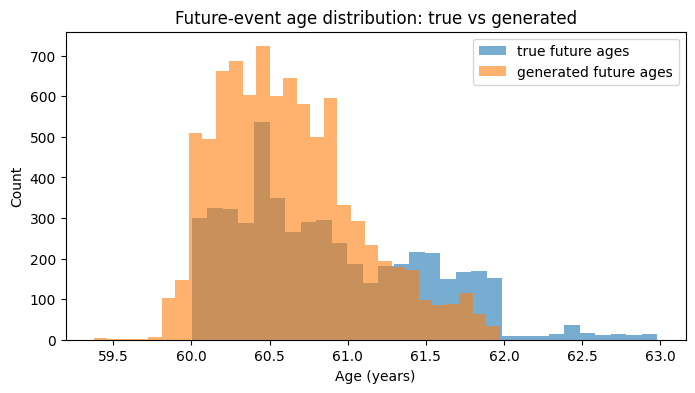

eligible cohort IDs: 5232
cohort patients sampled: 100
cohort patients used: 97
true future events: 5124 | generated future events: 8753
cohort source DATA_PATH: ../data/dose/kr_test.bin


In [9]:
# =========================
# Optional: cohort-level distribution comparison
# =========================

if RUN_COHORT_SAMPLING:
    import re

    no_event_token = name_to_token.get("No event", None)

    n_tokens = int(getattr(model.config, "data_vocab_size", getattr(model.config, "vocab_size", len(token_to_name))))
    n_age_bins = int(MAX_AGE_YEARS) + 1
    syn_counts = np.zeros((n_tokens, n_age_bins), dtype=np.float64)
    real_counts = np.zeros((n_tokens, n_age_bins), dtype=np.float64)
    syn_py = np.zeros(n_age_bins, dtype=np.float64)
    real_py = np.zeros(n_age_bins, dtype=np.float64)

    # Cohort eligibility:
    # 1) has history before COHORT_PREFIX_AGE_YEARS
    # 2) has observed follow-up after COHORT_REQUIRE_POST_AGE_YEARS
    # 3) has enough events
    ages_y_all = raw_data["AGE"].astype(np.float64) / 365.25
    ids_all, counts_all = np.unique(raw_data["ID"], return_counts=True)
    ids_min_events = ids_all[counts_all >= COHORT_MIN_EVENTS]
    ids_pre = np.unique(raw_data["ID"][ages_y_all < COHORT_PREFIX_AGE_YEARS])
    ids_post = np.unique(raw_data["ID"][ages_y_all > COHORT_REQUIRE_POST_AGE_YEARS])

    eligible_ids = np.intersect1d(np.intersect1d(ids_min_events, ids_pre), ids_post)
    if len(eligible_ids) == 0:
        raise ValueError(
            "No eligible cohort under current constraints. "
            "Try lowering COHORT_MIN_EVENTS or COHORT_PREFIX_AGE_YEARS."
        )

    rng = np.random.default_rng(SEED)
    n_pick = min(COHORT_N_PATIENTS, len(eligible_ids))
    pick_ids = rng.choice(eligible_ids, size=n_pick, replace=False)

    gen_tokens, gen_ages = [], []
    true_tokens, true_ages = [], []
    used_ids = []

    def _add_person_years(py_arr, start_age_y, end_age_y):
        if not np.isfinite(start_age_y) or not np.isfinite(end_age_y):
            return
        lo = max(0, int(np.floor(min(start_age_y, end_age_y))))
        hi = min(n_age_bins - 1, int(np.floor(max(start_age_y, end_age_y))))
        if hi >= lo:
            py_arr[lo:hi + 1] += 1.0

    for pid in pick_ids:
        sub = get_patient_slice(raw_data, int(pid))
        d = sub["DATA"].astype(np.int64) + token_offset
        a = sub["AGE"].astype(np.float32)
        a_y = a / 365.25

        # prefix cut = last event at/before COHORT_PREFIX_AGE_YEARS
        cidx = int(np.searchsorted(a_y, COHORT_PREFIX_AGE_YEARS, side='right'))
        if cidx < 2 or cidx >= len(d):
            continue

        if shift_continuous:
            s = sub["SHIFT"].astype(np.float32)
            x_s = torch.tensor(s[:cidx], device=device, dtype=torch.float32).unsqueeze(0)
        else:
            s = np.rint(sub["SHIFT"]).astype(np.int64)
            x_s = torch.tensor(s[:cidx], device=device, dtype=torch.long).unsqueeze(0)

        t = sub["TOTAL"].astype(np.int64)

        x_d = torch.tensor(d[:cidx], device=device, dtype=torch.long).unsqueeze(0)
        x_a = torch.tensor(a[:cidx], device=device, dtype=torch.float32).unsqueeze(0)
        x_t = torch.tensor(t[:cidx], device=device, dtype=torch.long).unsqueeze(0)

        with torch.no_grad():
            yd, ys, yt, ya, _ = model.generate(
                data=x_d,
                shift=x_s,
                total=x_t,
                age=x_a,
                max_new_tokens=COHORT_MAX_NEW_TOKENS,
                max_age=MAX_AGE_YEARS * 365.25,
                no_repeat=NO_REPEAT,
                termination_tokens=[death_token],
            )

        gd = yd[0].detach().cpu().numpy().astype(np.int64)
        ga = ya[0].detach().cpu().numpy().astype(np.float32)
        gd, ga = trim_after_first_termination(gd, ga, cidx, death_token)

        # observed future from same person (strictly after cohort prefix age)
        true_d_future = d[cidx:]
        true_a_future = a[cidx:]
        true_a_future_y = true_a_future / 365.25
        if len(true_d_future) == 0:
            continue

        obs_end_age_y = float(true_a_future_y[-1])

        # generated future from same person prefix
        gen_d_future = gd[cidx:]
        gen_a_future = ga[cidx:]
        gen_a_future_y = gen_a_future / 365.25

        # Optional: compare within each patient's observed follow-up horizon
        if COHORT_MATCH_OBS_FOLLOWUP and len(gen_d_future) > 0:
            keep = gen_a_future_y <= obs_end_age_y
            gen_d_future = gen_d_future[keep]
            gen_a_future = gen_a_future[keep]
            gen_a_future_y = gen_a_future_y[keep]

        # Person-years by age band (same cohort, same follow-up anchor)
        start_age_y = float(COHORT_PREFIX_AGE_YEARS)
        _add_person_years(real_py, start_age_y, obs_end_age_y)
        gen_end_age_y = float(gen_a_future_y[-1]) if len(gen_a_future_y) > 0 else start_age_y
        _add_person_years(syn_py, start_age_y, gen_end_age_y)

        # Exclude No event token for incidence counting
        if no_event_token is not None:
            tmask = true_d_future != no_event_token
            gmask = gen_d_future != no_event_token
            true_d_future = true_d_future[tmask]
            true_a_future = true_a_future[tmask]
            true_a_future_y = true_a_future_y[tmask]
            gen_d_future = gen_d_future[gmask]
            gen_a_future = gen_a_future[gmask]
            gen_a_future_y = gen_a_future_y[gmask]

        # Incidence tensors: token x age(year)
        if len(gen_d_future) > 0:
            g_age_idx = np.floor(gen_a_future_y).astype(np.int64)
            g_ok = (
                (gen_d_future >= 0) & (gen_d_future < n_tokens) &
                (g_age_idx >= 0) & (g_age_idx < n_age_bins)
            )
            if np.any(g_ok):
                np.add.at(syn_counts, (gen_d_future[g_ok], g_age_idx[g_ok]), 1.0)

        if len(true_d_future) > 0:
            t_age_idx = np.floor(true_a_future_y).astype(np.int64)
            t_ok = (
                (true_d_future >= 0) & (true_d_future < n_tokens) &
                (t_age_idx >= 0) & (t_age_idx < n_age_bins)
            )
            if np.any(t_ok):
                np.add.at(real_counts, (true_d_future[t_ok], t_age_idx[t_ok]), 1.0)

        gen_tokens.extend(gen_d_future.tolist())
        gen_ages.extend(gen_a_future_y.tolist())
        true_tokens.extend(true_d_future.tolist())
        true_ages.extend(true_a_future_y.tolist())
        used_ids.append(int(pid))

    if len(used_ids) == 0:
        raise ValueError("No cohort patients remained after 60y cut/filtering.")

    syn_inc = syn_counts / np.clip(syn_py[None, :], 1e-8, None)
    real_inc = real_counts / np.clip(real_py[None, :], 1e-8, None)

    chapter_order = [
        'Technical', 'Sex', 'Smoking, Alcohol and BMI',
        'I. Infectious Diseases', 'II. Neoplasms', 'III. Blood & Immune Disorders',
        'IV. Metabolic Diseases', 'V. Mental Disorders',
        'VI. Nervous System Diseases', 'VII. Eye Diseases',
        'VIII. Ear Diseases', 'IX. Circulatory Diseases',
        'X. Respiratory Diseases', 'XI. Digestive Diseases',
        'XII. Skin Diseases', 'XIII. Musculoskeletal Diseases',
        'XIV. Genitourinary Diseases', 'XV. Pregnancy & Childbirth',
        'XVI. Perinatal Conditions', 'XVII. Congenital Abnormalities', 'Death'
    ]

    chapter_colors = {
        ch: plt.get_cmap('tab20')(i % 20)
        for i, ch in enumerate(chapter_order)
    }

    def _chapter_from_name(name: str) -> str:
        if name in {'Padding', 'No event'}:
            return 'Technical'
        if name in {'Female', 'Male'}:
            return 'Sex'
        if name.startswith('BMI_') or name.startswith('Smoking_') or name.startswith('Alcohol_'):
            return 'Smoking, Alcohol and BMI'
        if name == 'Death':
            return 'Death'

        m = re.match(r'^([A-Z])(\d{2})\b', str(name))
        if not m:
            return 'Technical'
        letter = m.group(1)
        num = int(m.group(2))

        if letter in {'A', 'B'}:
            return 'I. Infectious Diseases'
        if letter == 'C':
            return 'II. Neoplasms'
        if letter == 'D':
            if 0 <= num <= 48:
                return 'II. Neoplasms'
            if 50 <= num <= 89:
                return 'III. Blood & Immune Disorders'
            return 'Technical'
        if letter == 'E':
            return 'IV. Metabolic Diseases'
        if letter == 'F':
            return 'V. Mental Disorders'
        if letter == 'G':
            return 'VI. Nervous System Diseases'
        if letter == 'H':
            if 0 <= num <= 59:
                return 'VII. Eye Diseases'
            if 60 <= num <= 95:
                return 'VIII. Ear Diseases'
            return 'Technical'
        if letter == 'I':
            return 'IX. Circulatory Diseases'
        if letter == 'J':
            return 'X. Respiratory Diseases'
        if letter == 'K':
            return 'XI. Digestive Diseases'
        if letter == 'L':
            return 'XII. Skin Diseases'
        if letter == 'M':
            return 'XIII. Musculoskeletal Diseases'
        if letter == 'N':
            return 'XIV. Genitourinary Diseases'
        if letter == 'O':
            return 'XV. Pregnancy & Childbirth'
        if letter == 'P':
            return 'XVI. Perinatal Conditions'
        if letter == 'Q':
            return 'XVII. Congenital Abnormalities'
        return 'Technical'

    delphi_labels = pd.DataFrame({
        'token': np.arange(n_tokens, dtype=np.int64),
        'name': [token_name(tok, token_to_name) for tok in range(n_tokens)],
    })
    delphi_labels['ICD-10 Chapter (short)'] = delphi_labels['name'].map(_chapter_from_name)
    delphi_labels['color'] = delphi_labels['ICD-10 Chapter (short)'].map(chapter_colors)

    df_gen = pd.Series(gen_tokens, name="token").value_counts().rename("generated_count")
    df_true = pd.Series(true_tokens, name="token").value_counts().rename("true_count")
    df_freq = pd.concat([df_true, df_gen], axis=1).fillna(0)
    df_freq["token_name"] = [token_name(tok, token_to_name) for tok in df_freq.index]
    df_freq["true_ratio"] = df_freq["true_count"] / max(df_freq["true_count"].sum(), 1)
    df_freq["generated_ratio"] = df_freq["generated_count"] / max(df_freq["generated_count"].sum(), 1)
    df_freq["ratio_diff_abs"] = (df_freq["true_ratio"] - df_freq["generated_ratio"]).abs()

    display(df_freq.sort_values("ratio_diff_abs", ascending=False).head(30))

    plt.figure(figsize=(8, 4))
    plt.hist(true_ages, bins=30, alpha=0.6, label="true future ages")
    plt.hist(gen_ages, bins=30, alpha=0.6, label="generated future ages")
    plt.xlabel("Age (years)")
    plt.ylabel("Count")
    plt.title("Future-event age distribution: true vs generated")
    plt.legend()
    plt.show()

    cohort_prefix_age_years = float(COHORT_PREFIX_AGE_YEARS)
    print("eligible cohort IDs:", len(eligible_ids))
    print("cohort patients sampled:", n_pick)
    print("cohort patients used:", len(used_ids))
    print("true future events:", len(true_tokens), "| generated future events:", len(gen_tokens))
    _cohort_source_path = DATA_PATH
    _cohort_used_ids = len(used_ids)
    print("cohort source DATA_PATH:", _cohort_source_path)
else:
    print("RUN_COHORT_SAMPLING=False -> skipped")

In [10]:
# =========================
# Disease-rate scatter (simulated vs observed)
# =========================

if not RUN_COHORT_SAMPLING:
    raise ValueError("Set RUN_COHORT_SAMPLING=True and run previous cell first.")
if 'syn_inc' not in globals() or 'real_inc' not in globals() or 'delphi_labels' not in globals():
    raise ValueError("Run the previous cohort sampling cell first.")

if globals().get('_cohort_source_path', None) != DATA_PATH:
    raise ValueError("syn_inc/real_inc were computed from a different DATA_PATH. Re-run the cohort cell after changing DATA_PATH.")

chapter_order = ['Technical', 'Sex', 'Smoking, Alcohol and BMI',
       'I. Infectious Diseases', 'II. Neoplasms', 'III. Blood & Immune Disorders',
       'IV. Metabolic Diseases', 'V. Mental Disorders',
       'VI. Nervous System Diseases', 'VII. Eye Diseases',
       'VIII. Ear Diseases', 'IX. Circulatory Diseases',
       'X. Respiratory Diseases', 'XI. Digestive Diseases',
       'XII. Skin Diseases', 'XIII. Musculoskeletal Diseases',
       'XIV. Genitourinary Diseases', 'XV. Pregnancy & Childbirth',
       'XVI. Perinatal Conditions', 'XVII. Congenital Abnormalities', 'Death']

ages_of_interest = [70, 71, 72, 73, 74]
if max(ages_of_interest) >= syn_inc.shape[1]:
    raise ValueError(f"ages_of_interest exceeds available age bins: max={syn_inc.shape[1]-1}")

age = int(globals().get('cohort_prefix_age_years', COHORT_PREFIX_AGE_YEARS))
x = syn_inc[:, ages_of_interest].mean(-1)
y = real_inc[:, ages_of_interest].mean(-1)
colors = delphi_labels['color'].to_numpy()
chapters = delphi_labels['ICD-10 Chapter (short)'].to_numpy()

# Plot only disease chapters (I~XVII)
disease_chapters = set(chapter_order[3:-1])
disease_mask = np.isin(chapters, list(disease_chapters))
finite_mask = disease_mask & np.isfinite(x) & np.isfinite(y)

both_pos = finite_mask & (x > 0) & (y > 0)
any_pos = finite_mask & ((x > 0) | (y > 0))

# Diagnostics for empty plot cases
print(f"tokens (disease chapters, finite): {int(finite_mask.sum())}")
print(f"tokens with x>0 and y>0: {int(both_pos.sum())}")
print(f"tokens with x>0 or y>0: {int(any_pos.sum())}")
if 'syn_py' in globals() and 'real_py' in globals():
    print("person-years in window (syn):", float(np.sum(syn_py[ages_of_interest])))
    print("person-years in window (real):", float(np.sum(real_py[ages_of_interest])))

# Primary: both positive. Fallback: one-sided positive.
if np.any(both_pos):
    mask = both_pos
elif np.any(any_pos):
    print("[fallback] no both-positive points; plotting one-sided positive points with epsilon clipping.")
    mask = any_pos
else:
    raise ValueError(
        "No incidence signal in this age window for the sampled cohort. "
        "Increase COHORT_N_PATIENTS / COHORT_MAX_NEW_TOKENS, or change ages_of_interest."
    )

eps = 1e-8
x_plot = np.clip(x, eps, None)
y_plot = np.clip(y, eps, None)

plt.figure(figsize=(4,4))
plt.scatter(x_plot[mask], y_plot[mask], marker='.', c=colors[mask])
plt.xlabel(f'Disease rate at ages {ages_of_interest[0]}-{ages_of_interest[-1]+1}, \nsimulated after age {age}\n[1/yr]')
plt.ylabel(f'Disease rate at ages {ages_of_interest[0]}-{ages_of_interest[-1]+1}, \nobserved\n[1/yr]')
plt.yscale('log')
plt.xscale('log')
plt.plot([0,1],[0,1], transform=plt.gca().transAxes, c='k', ls=':')
plt.xlim(1e-5, 10)
plt.ylim(1e-5, 10)

for chapter in chapter_order[3:-1]:
    subset = delphi_labels[delphi_labels['ICD-10 Chapter (short)'] == chapter]
    if len(subset) == 0:
        continue
    color = subset['color'].values[0]
    plt.scatter([], [], c=[color], label=chapter)

plt.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), frameon=False)
plt.show()

tokens (disease chapters, finite): 1255
tokens with x>0 and y>0: 0
tokens with x>0 or y>0: 0
person-years in window (syn): 0.0
person-years in window (real): 0.0


ValueError: No incidence signal in this age window for the sampled cohort. Increase COHORT_N_PATIENTS / COHORT_MAX_NEW_TOKENS, or change ages_of_interest.